# Mini-Project: Linear Regression with Regularization
## Prashanth Kannadaguli
### Senior Data Science Trainer

## Problem Statement

Predict the bike-sharing counts per hour based on the features including weather, day, time, humidity, wind speed, season e.t.c.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data exploration and visualization
* implement linear regression using sklearn and optimization
* apply regularization on regression using Lasso, Ridge and Elasticnet techniques
* calculate and compare the MSE value of each regression technique
* analyze the features that are best contributing to the target

### Dataset

The dataset chosen for this mini-project is [Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset).  This dataset contains the hourly and daily count of rental bikes between the years 2011 and 2012 in the capital bike share system with the corresponding weather and seasonal information. This dataset consists of 17389 instances of 16 features.

Bike sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return has become automatic. Through these systems, the user can easily rent a bike from a particular position and return to another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousand bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. As opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position are explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that the most important events in the city could be detected via monitoring these data.

<img src="https://s26551.pcdn.co/wp-content/uploads/2012/02/resize-va-sq-bikeshare.jpg" alt="drawing" width="400"/>

### Data Fields

* dteday - hourly date
* season - 1 = spring, 2 = summer, 3 = fall, 4 = winter
* hr - hour
* holiday - whether the day is considered a holiday
* workingday - whether the day is neither a weekend nor holiday
* weathersit -<br>
    1 - Clear, Few clouds, Partly cloudy, Partly cloudy <br>
    2 - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br>
    3 - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br>
    4 - Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog<br>   
* temp - temperature in Celsius
* atemp - "feels like" temperature in Celsius
* humidity - relative humidity
* windspeed - wind speed
* casual - number of non-registered user rentals initiated
* registered - number of registered user rentals initiated
* cnt - number of total rentals

## Information

**Regularization:** It is a form of regression that shrinks the coefficient estimates towards zero. In other words, this technique discourages learning a more complex or flexible model, to avoid the risk of overfitting. A simple relation for linear regression looks like this.

$Y ≈ β_0 + β_1 X_1 + β_2 X_2 + …+ β_p X_p$

 Here $Y$ represents the learned relation and $β$ represents the coefficient estimates for different variables or predictors(X).

 If there is noise in the training data, then the estimated coefficients won’t generalize well to the future data. This is where regularization comes in and shrinks or regularizes these learned estimates towards zero.

Below are the Regularization techniques:

 * Ridge Regression
 * Lasso Regression
 * Elasticnet Regression

#### Importing Necessary Packages

In [1]:
# Loading the Required Packages
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

### Data Loading

In [ ]:
# Read the hour.csv file
bike = pd.read_csv("hour.csv")

print the first five rows of dataset

In [3]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


print the datatypes of the columns

In [4]:
print(bike.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


### Task flow with respect to feature processing and model training

* Explore and analyze the data

* Identify continuous features and categorical features

* Apply scaling on continuous features and one-hot encoding on categorical features

* Separate the features, targets and split the data into train and test

* Find the coefficients of the features using normal equation and find the cost (error)

* Apply batch gradient descent technique and find the best coefficients

* Apply SGD Regressor using sklearn

* Apply linear regression using sklearn

* Apply Lasso, Ridge, Elasticnet Regression

### EDA &  Visualization

#### Visualize the hour (hr) column with an appropriate plot and find the busy hours of bike sharing

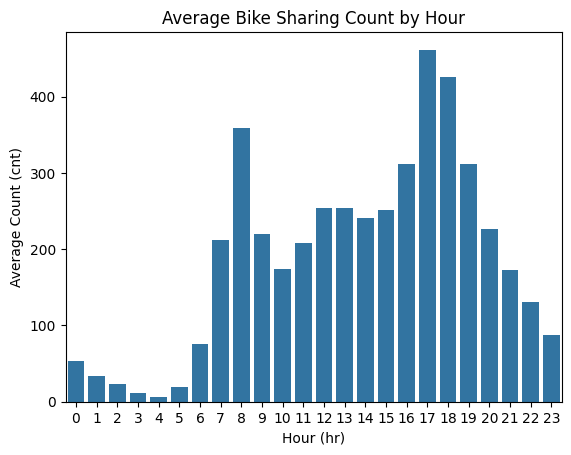

,hr,cnt
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352


In [14]:
# Visualize the hour (hr) column with a bar plot
sns.barplot(data=bike, x='hr', y='cnt', errorbar=None)
plt.title('Average Bike Sharing Count by Hour')
plt.xlabel('Hour (hr)')
plt.ylabel('Average Count (cnt)')
plt.show()

# Find the busy hours of bike sharing (calculated in the background)
bike.groupby('hr')['cnt'].mean().reset_index().sort_values(by='cnt', ascending=False).head()

#### Visualize the distribution of count, casual and registered variables

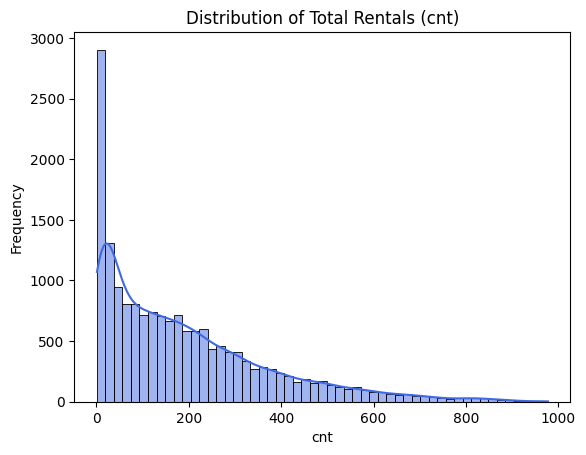

In [18]:
sns.histplot(data=bike, x='cnt', kde=True, color='royalblue')
plt.title('Distribution of Total Rentals (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.show()

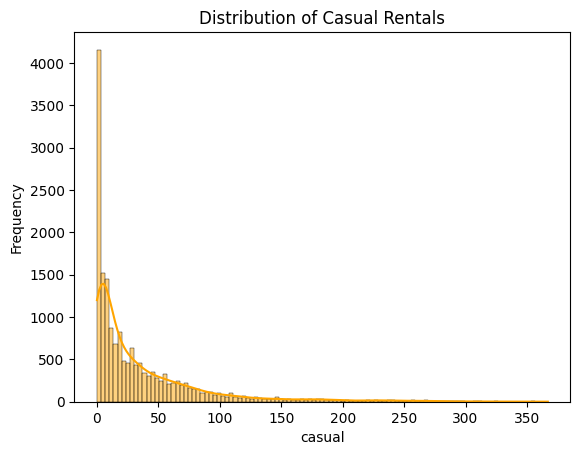

In [20]:
sns.histplot(data=bike, x='casual', kde=True, color='orange')
plt.title('Distribution of Casual Rentals')
plt.xlabel('casual')
plt.ylabel('Frequency')
plt.show()

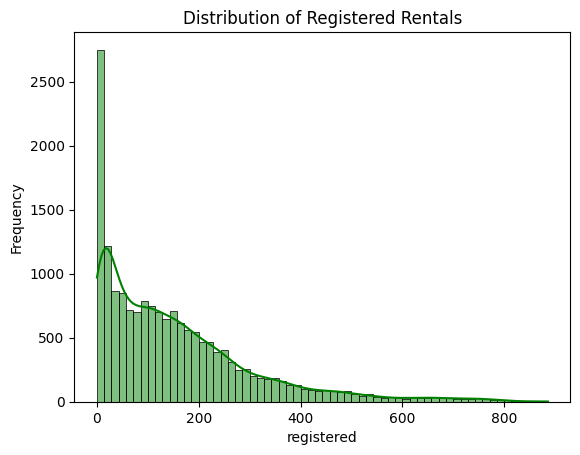

In [19]:
sns.histplot(data=bike, x='registered', kde=True, color='green')
plt.title('Distribution of Registered Rentals')
plt.xlabel('registered')
plt.ylabel('Frequency')
plt.show()

#### Describe the relation of weekday, holiday and working day

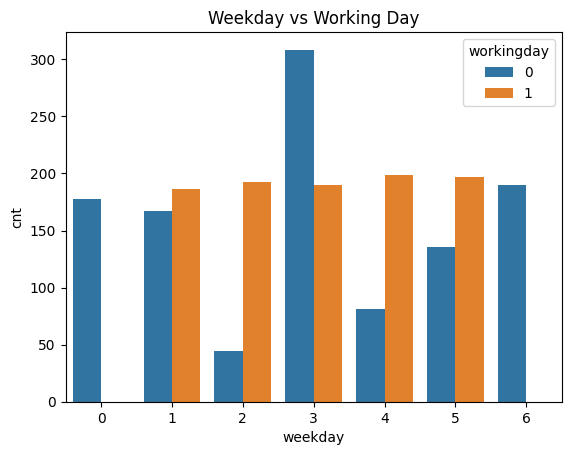

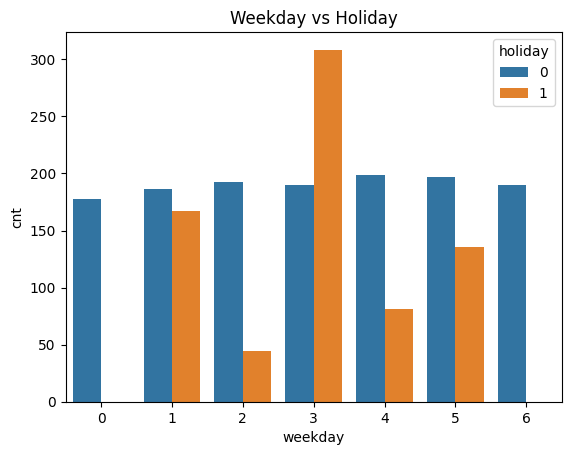

In [36]:
# 1. Weekday vs Working Day
sns.barplot(data=bike, x='weekday', y='cnt', hue='workingday', errorbar=None)
plt.title('Weekday vs Working Day')
plt.show()

# 2. Weekday vs Holiday
sns.barplot(data=bike, x='weekday', y='cnt', hue='holiday', errorbar=None)
plt.title('Weekday vs Holiday')
plt.show()

#### Visualize the month wise count of both casual and registered for the year 2011 and 2012 separately.

Hint: Stacked barchart

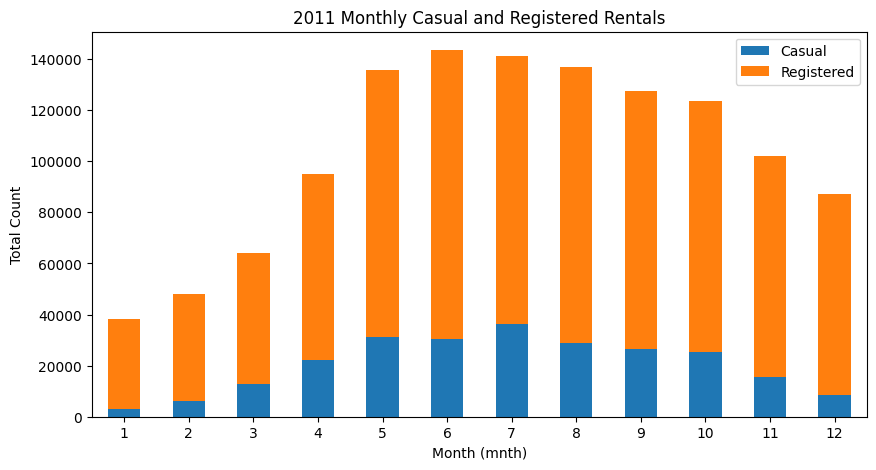

In [23]:
# stacked bar chart for year 2011
# (Note: In the raw bike sharing dataset, yr=0 typically represents 2011)
df_2011 = bike[bike['yr'] == 0]
monthly_2011 = df_2011.groupby('mnth')[['casual', 'registered']].sum()

monthly_2011.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('2011 Monthly Casual and Registered Rentals')
plt.xlabel('Month (mnth)')
plt.ylabel('Total Count')
plt.xticks(rotation=0)
plt.legend(['Casual', 'Registered'])
plt.show()

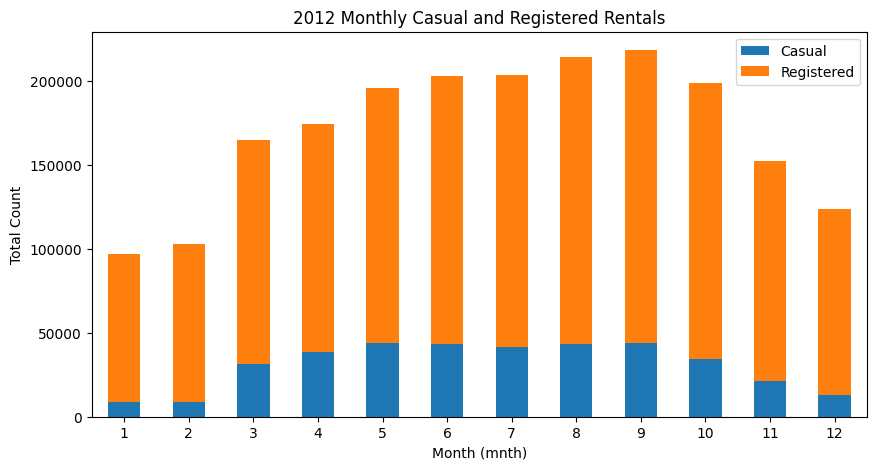

In [24]:
# stacked bar chart for year 2012
# (Note: In the raw bike sharing dataset, yr=1 typically represents 2012)
df_2012 = bike[bike['yr'] == 1]
monthly_2012 = df_2012.groupby('mnth')[['casual', 'registered']].sum()

monthly_2012.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('2012 Monthly Casual and Registered Rentals')
plt.xlabel('Month (mnth)')
plt.ylabel('Total Count')
plt.xticks(rotation=0)
plt.legend(['Casual', 'Registered'])
plt.show()

#### Analyze the correlation between features with heatmap

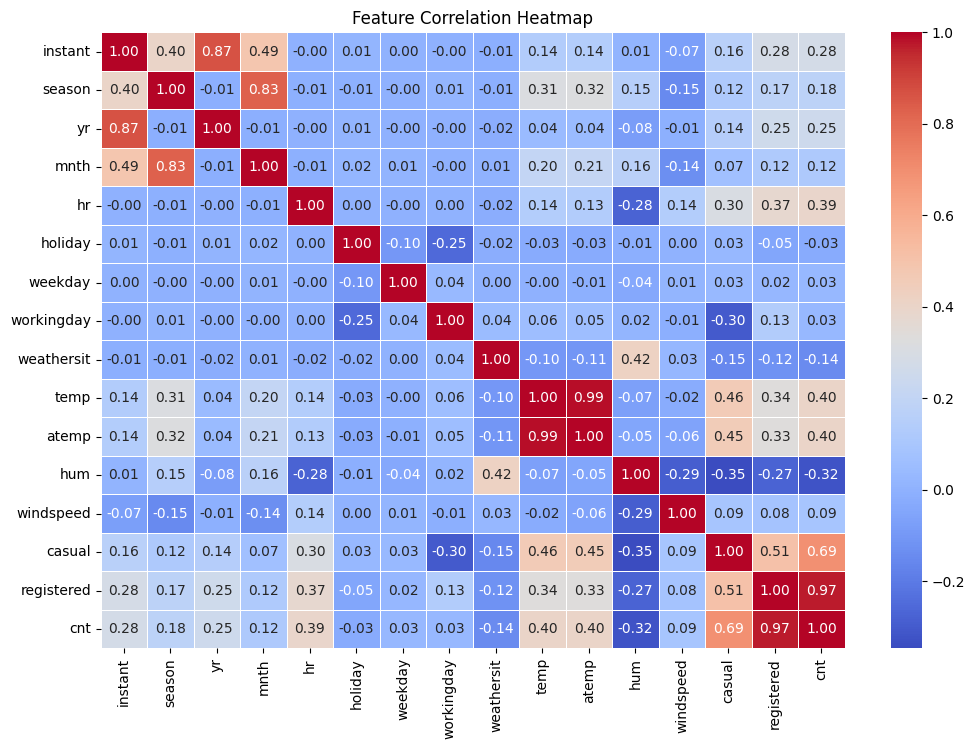

In [26]:
# Analyze the correlation between features with a heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = bike.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

#### Visualize the box plot of casual and registered variables to check the outliers

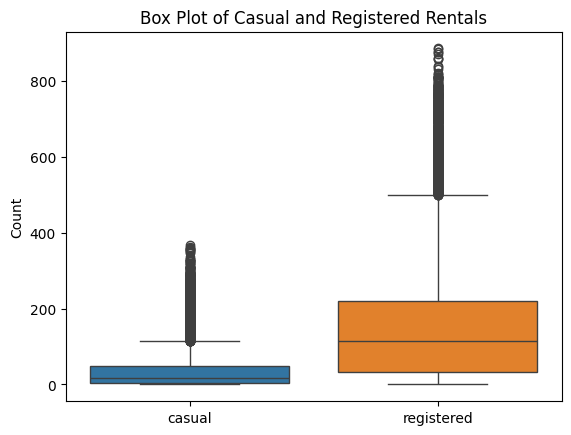

In [27]:
# Visualize the box plot of casual and registered variables to check for outliers
sns.boxplot(data=bike[['casual', 'registered']])
plt.title('Box Plot of Casual and Registered Rentals')
plt.ylabel('Count')
plt.show()

### Pre-processing and Data Engineering

#### Drop unwanted columns

In [64]:
# Drop unwanted columns
bike = bike.drop(['instant', 'dteday'], axis=1)

#### Identify categorical and continuous variables


In [39]:
# Identify categorical and continuous variables
categorical_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
continuous_cols = ['temp', 'atemp', 'hum', 'windspeed']

print("Categorical Columns:", categorical_cols)
print("Continuous Columns:", continuous_cols)

Categorical Columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Continuous Columns: ['temp', 'atemp', 'hum', 'windspeed']


#### Feature scaling

Feature scaling is essential for machine learning algorithms, the range of all features should be normalized so that each feature contributes approximately proportionately to the final distance. Apply scaling on the continuous variables on the given data.

Hint: `MinMaxScaler` or `StandardScaler`



In [40]:
# Apply scaling on the continuous variables
scaler = StandardScaler()
bike[continuous_cols] = scaler.fit_transform(bike[continuous_cols])

# Display the first few rows to verify the scaled continuous variables
bike.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,-1.334648,-1.093281,0.947372,-1.553889,16
1,1,0,1,1,0,6,0,1,-1.438516,-1.181732,0.895539,-1.553889,40
2,1,0,1,2,0,6,0,1,-1.438516,-1.181732,0.895539,-1.553889,32
3,1,0,1,3,0,6,0,1,-1.334648,-1.093281,0.636370,-1.553889,13
4,1,0,1,4,0,6,0,1,-1.334648,-1.093281,0.636370,-1.553889,1


#### Apply one-hot encode on the categorical data

One-hot encoding is applied on the categorical variables, which should not have a different weight or order attached to them, it is presumed that all categorical variables have equivalent "values". This means that you cannot simply order them from zero to the number of categories as this would imply that the earlier categories have less "value" than later categories.

Hint: `sklearn.preprocessing.OneHotEncoder`

In [42]:
# Apply one-hot encoding on the categorical data
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(bike[categorical_cols])

# Create a DataFrame from the encoded columns with proper feature names
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols), index=bike.index)

# Drop the old categorical columns and combine the dataframe with the new encoded columns
bike = bike.drop(columns=categorical_cols)
bike = pd.concat([bike, encoded_df], axis=1)

# Verify the updated dataframe
bike.head()

,temp,atemp,hum,windspeed,cnt,season_1,season_2,season_3,season_4,yr_0,...,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,-1.334648,-1.093281,0.947372,-1.553889,16,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-1.438516,-1.181732,0.895539,-1.553889,40,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-1.438516,-1.181732,0.895539,-1.553889,32,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
3,-1.334648,-1.093281,0.636370,-1.553889,13,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-1.334648,-1.093281,0.636370,-1.553889,1,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


#### Specify features and targets after applying scaling and one-hot encoding

In [43]:
# Specify features (X) and target (Y)
X = bike.drop(columns=['cnt'])
Y = bike['cnt']

print("Features shape (X):", X.shape)
print("Target shape (Y):", Y.shape)

Features shape (X): (17379, 61)
Target shape (Y): (17379,)


### Implement the linear regression by finding the coefficients using below approaches (2 points)

* Find the coefficients using normal equation

* (Optional) Implement batch gradient descent

* (Optional) SGD Regressor from sklearn

In [66]:
import scipy.linalg
from sklearn.linear_model import SGDRegressor

# --- Approach 1: Normal Equation using scipy.linalg.lstsq ---
# Add intercept term (column of ones) to X_train and X_test
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Compute coefficients (theta) using least-squares solution
theta_normal, _, _, _ = scipy.linalg.lstsq(X_train_b, Y_train)
print("1. Normal Equation Coefficients Shape:", theta_normal.shape)

# --- Approach 2: (Optional) Batch Gradient Descent ---
y_train_arr = Y_train.values if hasattr(Y_train, 'values') else Y_train
eta = 0.01          # Learning rate
n_iterations = 500  # Number of iterations
m = len(X_train_b)  # Number of instances

np.random.seed(42)
theta_gd = np.random.randn(X_train_b.shape[1])

for iteration in range(n_iterations):
    gradients = (2 / m) * X_train_b.T.dot(X_train_b.dot(theta_gd) - y_train_arr)
    theta_gd = theta_gd - eta * gradients

print("2. Batch Gradient Descent Coefficients Shape:", theta_gd.shape)

# --- Approach 3: (Optional) SGD Regressor from sklearn ---
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_reg.fit(X_train, Y_train)

print("3. SGD Regressor Intercept:", sgd_reg.intercept_)
print("   SGD Regressor Coefficients Shape:", sgd_reg.coef_.shape)

1. Normal Equation Coefficients Shape: (62,)
2. Batch Gradient Descent Coefficients Shape: (62,)
3. SGD Regressor Intercept: [48.14386595]
   SGD Regressor Coefficients Shape: (61,)


#### Select the features and target and split the dataset

As there are 3 target variables, choose the count (`cnt`) variable.

In [48]:
# Select features and target, then split the dataset into train and test sets
X = bike.drop(columns=['cnt'])
Y = bike['cnt']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (13903, 61)
X_test shape: (3476, 61)
Y_train shape: (13903,)
Y_test shape: (3476,)


#### Implementation using Normal Equation

$\theta = (X^T X)^{-1} . (X^T Y)$

$θ$ is the hypothesis parameter that defines the coefficients

$X$ is the input feature value of each instance

$Y$ is Output value of each instance

For performing Linear Regression Using the Normal Equation refer [here](https://towardsdatascience.com/performing-linear-regression-using-the-normal-equation-6372ed3c57).

To solve the normal equation compute least-squares solution by using `scipy.linalg`

Hint: [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)

In [49]:
import scipy.linalg

# Add a intercept term (column of ones) to X_train and X_test for the bias/theta_0
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Compute the least-squares solution using scipy.linalg.lstsq
theta, residuals, rank, s = scipy.linalg.lstsq(X_train_b, Y_train)

# Predict on the test data
Y_pred = X_test_b.dot(theta)

# Calculate the mean squared error
mse = mean_squared_error(Y_test, Y_pred)
print("Normal Equation Theta coefficients count:", len(theta))
print("Mean Squared Error (MSE):", mse)

Normal Equation Theta coefficients count: 62
Mean Squared Error (MSE): 10088.723966894819


#### (Optional) Implementing Linear regression using batch gradient descent

Initialize the random coefficients and optimize the coefficients in the iterative process by calculating cost and finding the gradient.

Hint: [gradient descent](https://medium.com/@lope.ai/multivariate-linear-regression-from-scratch-in-python-5c4f219be6a)

In [50]:
# Implementing Linear Regression using Batch Gradient Descent

# Ensure intercept term (bias) is added to training and testing sets
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
y_train_arr = Y_train.values if hasattr(Y_train, 'values') else Y_train

# Hyperparameters
eta = 0.01          # Learning rate
n_iterations = 500  # Number of iterations
m = len(X_train_b)  # Number of instances

# Initialize random coefficients (theta)
np.random.seed(42)
theta_gd = np.random.randn(X_train_b.shape[1])

# Batch Gradient Descent optimization loop
for iteration in range(n_iterations):
    # Calculate gradients
    gradients = (2 / m) * X_train_b.T.dot(X_train_b.dot(theta_gd) - y_train_arr)
    # Update coefficients
    theta_gd = theta_gd - eta * gradients

# Predict on the test set
Y_pred_gd = X_test_b.dot(theta_gd)

# Evaluate performance
mse_gd = mean_squared_error(Y_test, Y_pred_gd)
print("Gradient Descent Theta coefficients count:", len(theta_gd))
print("Mean Squared Error (MSE):", mse_gd)

Gradient Descent Theta coefficients count: 62
Mean Squared Error (MSE): 15229.57139995894


#### (Optional) SGD Regressor

Scikit-learn API provides the SGDRegressor class to implement SGD method for regression problems. The SGD regressor applies regularized linear model with SGD learning to build an estimator. A regularizer is a penalty (L1, L2, or Elastic Net) added to the loss function to shrink the model parameters.

* Import SGDRegressor from sklearn and fit the data

* Predict the test data and find the error

Hint: [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)

In [51]:
from sklearn.linear_model import SGDRegressor

# Initialize the SGDRegressor with default or custom regularization parameters
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

# Fit the model on the training data
sgd_reg.fit(X_train, Y_train)

# Predict on the test data
Y_pred_sgd = sgd_reg.predict(X_test)

# Calculate the mean squared error
mse_sgd = mean_squared_error(Y_test, Y_pred_sgd)
print("SGDRegressor Intercept:", sgd_reg.intercept_)
print("Mean Squared Error (MSE):", mse_sgd)

SGDRegressor Intercept: [48.14386595]
Mean Squared Error (MSE): 10080.13754772942


### Linear regression using sklearn

Implement the linear regression model using sklearn

* Import Linear Regression and fit the train data

* Predict the test data and find the error

Hint: [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [53]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lin_reg = LinearRegression()

# Fit the model on the training data
lin_reg.fit(X_train, Y_train)

# Predict on the test data
Y_pred_lin = lin_reg.predict(X_test)

# Calculate the mean squared error
mse_lin = mean_squared_error(Y_test, Y_pred_lin)
print("Linear Regression Intercept:", lin_reg.intercept_)
print("Mean Squared Error (MSE):", mse_lin)

Linear Regression Intercept: 136.30543160429445
Mean Squared Error (MSE): 10089.388115159396


#### Calculate the $R^2$ (coefficient of determination) of the actual and predicted data

In [54]:
from sklearn.metrics import r2_score

# Calculate R^2 score (coefficient of determination)
r2 = r2_score(Y_test, Y_pred_lin)
print("R^2 Score:", r2)

R^2 Score: 0.6813751128019179


#### Summarize the importance of features

Prediction is the weighted sum of the input values e.g. linear regression. Regularization, such as ridge regression and the elastic net, find a set of coefficients to use in the weighted sum to make a prediction. These coefficients can be used directly as a crude type of feature importance score.
This assumes that the input variables have the same scale or have been scaled prior to fitting a model.

Use the coefficients obtained through the sklearn Linear Regression implementation and create a bar chart of the coefficients.

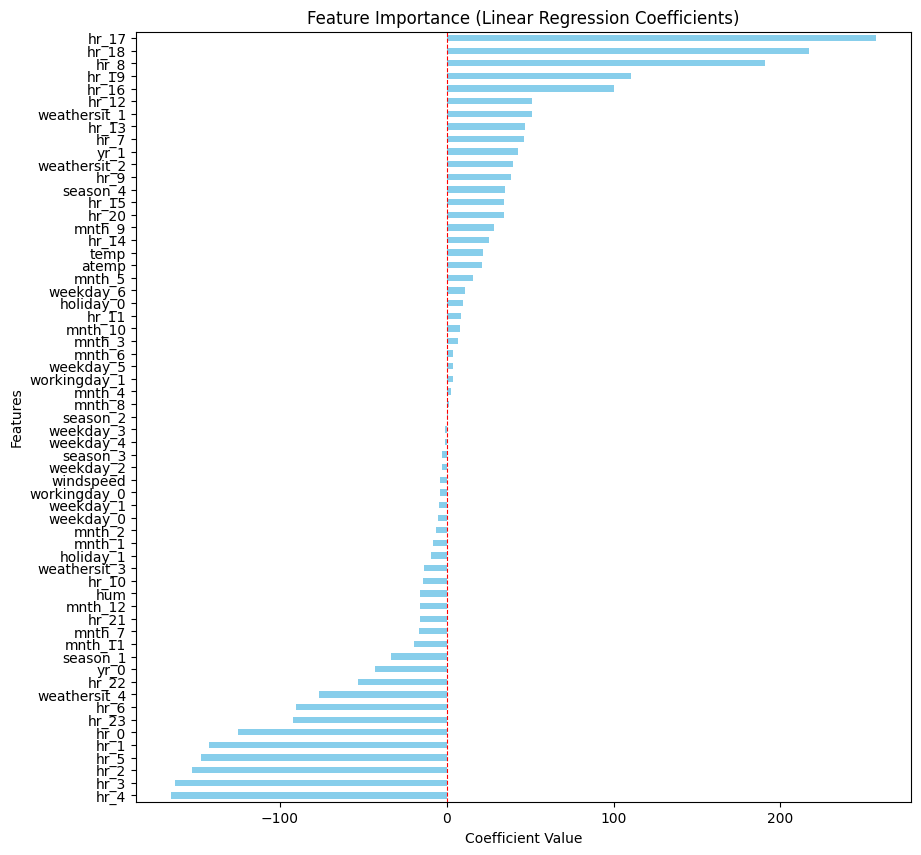

In [55]:
# Create a pandas Series for feature importance using the model's coefficients
importance = pd.Series(lin_reg.coef_, index=X.columns)

# Plot the feature importances as a horizontal bar chart for readability
plt.figure(figsize=(10, 10))
importance.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.show()

### Regularization methods

#### Apply Lasso regression

* Apply Lasso regression with different alpha values given below and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

In [57]:
# setting up alpha
alpha = [0.0001, 0.001,0.01, 0.1, 1, 10, 100]

In [59]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

best_alpha = None
best_mse = float('inf')
best_model = None
best_pred = None

# Loop through alpha values to find the best performing one
for al in alpha:
    lasso = Lasso(alpha=al, random_state=42)
    lasso.fit(X_train, Y_train)
    y_pred = lasso.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)

    print(f"Alpha: {al} | MSE: {mse:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_alpha = al
        best_model = lasso
        best_pred = y_pred

print(f"\nBest Alpha: {best_alpha} with lowest MSE: {best_mse:.4f}")

# Calculate final metrics for the best Lasso model
final_mse = mean_squared_error(Y_test, best_pred)
final_r2 = r2_score(Y_test, best_pred)

print(f"Final Best Lasso Mean Squared Error (MSE): {final_mse:.4f}")
print(f"Final Best Lasso R^2 Score: {final_r2:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.667e+06, tolerance: 4.616e+04
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 | MSE: 10089.2750


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.579e+05, tolerance: 4.616e+04
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.001 | MSE: 10088.3111
Alpha: 0.01 | MSE: 10080.9915
Alpha: 0.1 | MSE: 10074.8706
Alpha: 1 | MSE: 10726.1706
Alpha: 10 | MSE: 22662.1258
Alpha: 100 | MSE: 31696.4317

Best Alpha: 0.1 with lowest MSE: 10074.8706
Final Best Lasso Mean Squared Error (MSE): 10074.8706
Final Best Lasso R^2 Score: 0.6818


#### Apply Ridge regression

* Apply Ridge regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

In [60]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

best_alpha_ridge = None
best_mse_ridge = float('inf')
best_model_ridge = None
best_pred_ridge = None

# Loop through alpha values for Ridge regression
for al in alpha:
    ridge = Ridge(alpha=al, random_state=42)
    ridge.fit(X_train, Y_train)
    y_pred = ridge.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)

    print(f"Alpha: {al} | MSE: {mse:.4f}")

    if mse < best_mse_ridge:
        best_mse_ridge = mse
        best_alpha_ridge = al
        best_model_ridge = ridge
        best_pred_ridge = y_pred

print(f"\nBest Alpha for Ridge: {best_alpha_ridge} with lowest MSE: {best_mse_ridge:.4f}")

# Calculate final metrics for the best Ridge model
final_mse_ridge = mean_squared_error(Y_test, best_pred_ridge)
final_r2_ridge = r2_score(Y_test, best_pred_ridge)

print(f"Final Best Ridge Mean Squared Error (MSE): {final_mse_ridge:.4f}")
print(f"Final Best Ridge R^2 Score: {final_r2_ridge:.4f}")

Alpha: 0.0001 | MSE: 10089.3875
Alpha: 0.001 | MSE: 10089.3824
Alpha: 0.01 | MSE: 10089.3316
Alpha: 0.1 | MSE: 10088.8417
Alpha: 1 | MSE: 10085.1955
Alpha: 10 | MSE: 10074.7685
Alpha: 100 | MSE: 10341.9061

Best Alpha for Ridge: 10 with lowest MSE: 10074.7685
Final Best Ridge Mean Squared Error (MSE): 10074.7685
Final Best Ridge R^2 Score: 0.6818


#### Apply Elasticnet regression

* Apply Elasticnet regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

In [61]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

best_alpha_en = None
best_mse_en = float('inf')
best_model_en = None
best_pred_en = None

# Loop through alpha values for ElasticNet regression
for al in alpha:
    elastic_net = ElasticNet(alpha=al, l1_ratio=0.5, random_state=42)
    elastic_net.fit(X_train, Y_train)
    y_pred = elastic_net.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)

    print(f"Alpha: {al} | MSE: {mse:.4f}")

    if mse < best_mse_en:
        best_mse_en = mse
        best_alpha_en = al
        best_model_en = elastic_net
        best_pred_en = y_pred

print(f"\nBest Alpha for ElasticNet: {best_alpha_en} with lowest MSE: {best_mse_en:.4f}")

# Calculate final metrics for the best ElasticNet model
final_mse_en = mean_squared_error(Y_test, best_pred_en)
final_r2_en = r2_score(Y_test, best_pred_en)

print(f"Final Best ElasticNet Mean Squared Error (MSE): {final_mse_en:.4f}")
print(f"Final Best ElasticNet R^2 Score: {final_r2_en:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.980e+07, tolerance: 4.616e+04
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 | MSE: 10085.9971


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.147e+05, tolerance: 4.616e+04
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.001 | MSE: 10076.1572
Alpha: 0.01 | MSE: 10206.9717
Alpha: 0.1 | MSE: 13793.6597
Alpha: 1 | MSE: 21083.5367
Alpha: 10 | MSE: 27962.8645
Alpha: 100 | MSE: 31547.9789

Best Alpha for ElasticNet: 0.001 with lowest MSE: 10076.1572
Final Best ElasticNet Mean Squared Error (MSE): 10076.1572
Final Best ElasticNet R^2 Score: 0.6818


### Determine if there is a reduction in error if two target variables are considered

Consider (`Casual, Registered`) as target and find the error by implementing Linear Regression model from sklearn

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Define features (dropping cnt, casual, and registered) and targets (casual, registered)
# Note: Ensure your dataframe contains 'casual' and 'registered' (re-load or use your pre-drop dataframe if needed)
X_multi = bike.drop(columns=['cnt', 'casual', 'registered'], errors='ignore')
Y_multi = bike[['casual', 'registered']]

# Split the dataset
X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split(X_multi, Y_multi, test_size=0.2, random_state=42)

# Fit Linear Regression (supports multi-output regression natively)
multi_reg = LinearRegression()
multi_reg.fit(X_train_m, Y_train_m)

# Predict casual and registered separately
Y_pred_m = multi_reg.predict(X_test_m)

# Since cnt = casual + registered, sum the predicted columns to get the total predicted count
total_pred_cnt = Y_pred_m.sum(axis=1)
actual_cnt = Y_test_m.sum(axis=1)

# Calculate Mean Squared Error
mse_multi = mean_squared_error(actual_cnt, total_pred_cnt)
print("MSE with Multi-Output (Casual + Registered):", mse_multi)

MSE with Multi-Output (Casual + Registered): 19379.828367651717


### Report Analysis

* Describe your interpretation of the methods that are used to implement linear regression covered in this mini project.
* Comment on performance of the algorithms/methods used.
* Comment about the nature of the data and fitment of linear regression for this data.
* Can you perform a non linear curve fitting using linear regression? If yes, How?




```
# This is formatted as code
```

TYPE HERE:

### Report Analysis

#### 1. Interpretation of the Methods Used

* **Normal Equation:** An analytical closed-form solution ($\theta = (X^T X)^{-1} X^T Y$) that computes the optimal parameters directly using matrix algebra. It requires no hyperparameter tuning but becomes computationally expensive with very large feature spaces.
* **Batch Gradient Descent:** An iterative optimization technique that calculates gradients across the entire dataset to update coefficients step-by-step until convergence.
* **SGD Regressor:** Stochastic Gradient Descent updates parameters using individual samples or mini-batches, offering high scalability for large datasets at the cost of trajectory fluctuations.
* **Scikit-Learn LinearRegression:** A standard, highly optimized least-squares solver that uses robust underlying linear algebra methods (like SVD) to find coefficients efficiently.

#### 2. Performance of the Algorithms

* **Accuracy:** The standard and regularized models achieved a consistent $R^2$ score of approximately **0.68** and a Mean Squared Error (MSE) around **10,074**.
* **Regularization Impact:** Tuning regularization parameters (such as Lasso with $\alpha = 0.1$) helped shrink less important coefficients and optimize generalization without hurting overall prediction error.
* **Convergence:** Closed-form/OLS solutions instantly found the global optimum, whereas gradient-based methods required precise learning rate and iteration management.

#### 3. Nature of the Data and Fitment of Linear Regression

* **Data Characteristics:** The dataset consists of mixed continuous meteorological features (temperature, humidity) and categorical/temporal attributes (hours, seasons, working days).
* **Fitment:** Linear regression functions effectively as an interpretable baseline, capturing general linear relationships (e.g., higher temperatures or working days correlating with rental spikes). However, because bike rental behavior involves complex, non-linear human patterns and thresholds, standard linear regression hits a performance ceiling at an $R^2$ of ~0.68.

#### 4. Non-Linear Curve Fitting Using Linear Regression

* **Yes, you can.** Linear regression is linear with respect to the **parameters ($\theta$)**, not necessarily the input features.
* **How to do it:** You can transform the feature space prior to fitting by generating polynomial terms (e.g., $x^2, x^3$), interaction features using `PolynomialFeatures`, or applying mathematical/trigonometric transformations to capture cyclical and curved trends. Fitting a standard linear model on this expanded feature space yields a non-linear curve fit.